In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

##Load Dataset

In [4]:
df= pd.read_csv('Twitter_Data.csv')

##Display Dataset

In [10]:
df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB


###Check Missing Values

In [6]:
df.isnull().sum()

,0
clean_text,4
category,7


###Remove Missing Values

In [13]:
df.dropna(inplace=True)

In [22]:
X = df['clean_text']
y = df['category']

###Convert Text into Numerical Form

In [21]:
vectorizer = CountVectorizer()

X_vectorized = vectorizer.fit_transform(X)

###Split Dataset into Training and Testing Data

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42
)

###Train Machine Learning Model

In [25]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [35]:
y_pred = model.predict(X_test)

Check Accuracy

In [27]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7482665521261582


Classification Report

In [28]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        -1.0       0.74      0.63      0.68      7152
         0.0       0.91      0.61      0.73     11067
         1.0       0.69      0.91      0.78     14375

    accuracy                           0.75     32594
   macro avg       0.78      0.72      0.73     32594
weighted avg       0.77      0.75      0.74     32594



Confusion Matrix

In [29]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 4502   309  2341]
 [  694  6799  3574]
 [  918   369 13088]]


##Visualization

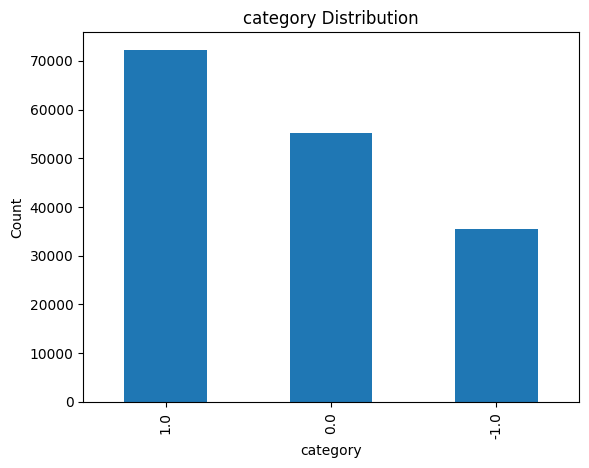

In [32]:
df['category'].value_counts().plot(kind='bar')

plt.xlabel("category")
plt.ylabel("Count")
plt.title("category Distribution")

plt.show()

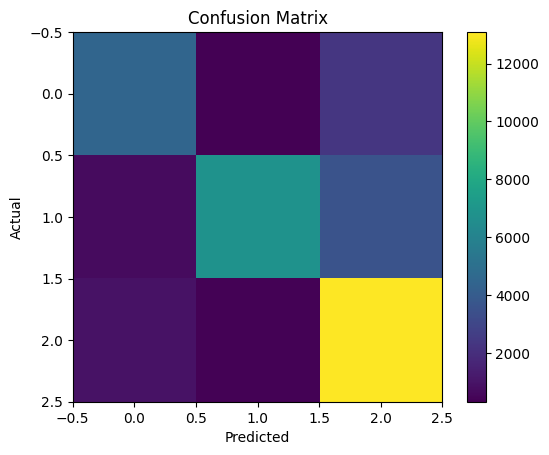

In [33]:
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

###Test with Custom Input

In [36]:
sample = ["This product is amazing"]

sample_vector = vectorizer.transform(sample)

prediction = model.predict(sample_vector)

print("Predicted Sentiment:", prediction[0])

Predicted Sentiment: 1.0
